# Netflix Movies and TV Shows Analysis

This project analyzes Netflix's catalog to understand trends in content distribution, growth patterns, and characteristics of movies and TV shows using Python, Pandas, Matplotlib, and Seaborn.

## Dataset Overview

The dataset used in this project contains information about movies and TV shows available on Netflix.

It includes attributes such as:

* Title
* Content type (Movie or TV Show)
* Country
* Release year
* Rating
* Duration
* Genre categories

The dataset contains approximately 8,800 entries representing Netflix content.

## Data Cleaning

Before performing analysis, the dataset was inspected and cleaned.

Steps performed:

* Checked for missing values
* Converted date columns to datetime format
* Removed or handled inconsistent values
* Prepared columns for analysis



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv(r"C:\Users\abhay\OneDrive\Desktop\Abhay Folder\Projects\Netflix Analysis\Data\netflix_titles.csv")
print(df.head(5))
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())


df["director"].fillna("Unknown",inplace=True)
df["cast"].fillna("Unknown",inplace=True)
df["country"].fillna("Unknown",inplace=True)
df["date_added"].fillna("Unknown",inplace=True)
df["rating"].fillna("Unknown",inplace=True)
df["duration"].fillna("Unknown",inplace=True)


print(df.isnull().sum())



  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

C:\Users\abhay\AppData\Local\Temp\ipykernel_27100\1041072337.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["director"].fillna("Unknown",inplace=True)
C:\Users\abhay\AppData\Local\Temp\ipykernel_27100\1041072337.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

## Analysis 1: Distribution of Movies vs TV Shows

This analysis examines whether Netflix's catalog is dominated by movies or television shows.
Understanding this distribution helps reveal Netflix's content strategy.


<bound method IndexOpsMixin.value_counts of 0         Movie
1       TV Show
2       TV Show
3       TV Show
4       TV Show
         ...   
8802      Movie
8803    TV Show
8804      Movie
8805      Movie
8806      Movie
Name: type, Length: 8807, dtype: object>


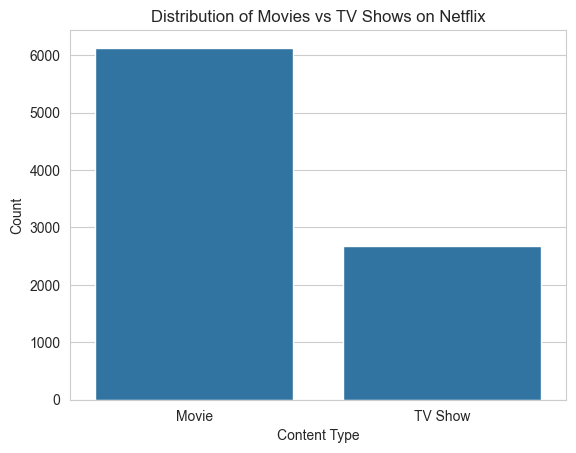

In [3]:
df["date_added"] = pd.to_datetime(df["date_added"],errors="coerce")
df["year_added"] = df["date_added"].dt.year

print(df["type"].value_counts)

sns.countplot(x="type",data=df)
plt.title("Distribution of Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()



### Insight

The analysis shows that movies significantly outnumber TV shows on Netflix, indicating that the platform's catalog is largely composed of film content.


## Analysis 2: Netflix Content Growth Over Time

This analysis examines how the number of titles added to Netflix has changed over the years.
Understanding this trend helps reveal the platform's expansion and growth strategy.


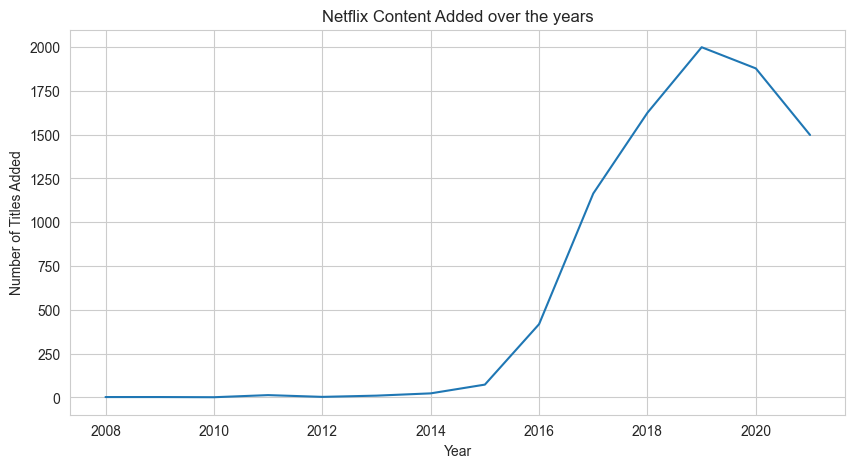

In [5]:
content_per_year = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(10,5))
content_per_year.plot(kind="line")

plt.title("Netflix Content Added over the years")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.show()

### Insight

The number of titles added to Netflix increased significantly after 2016.
This suggests that Netflix expanded its content library rapidly during this period, likely due to the growing popularity of streaming services worldwide.


## Analysis 3: Countries Producing the Most Netflix Content

This section analyzes which countries contribute the largest number of titles to Netflix's catalog.
The goal is to understand the global distribution of content production on the platform.


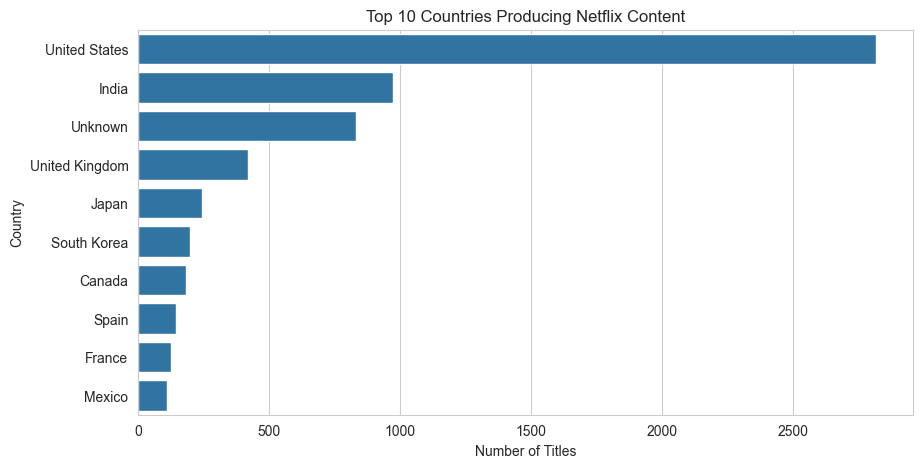

In [6]:
top_countries = df['country'].value_counts().head(10)
top_countries

plt.figure(figsize=(10,5))

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()


### Insight

The United States produces the highest number of titles on Netflix, followed by countries such as India and the United Kingdom.
This highlights the strong presence of American content while also showing Netflix's growing international reach.


## Analysis 4: Distribution of Content Ratings

This analysis investigates the distribution of content ratings available on Netflix.
Ratings indicate the intended audience for each title, ranging from children's programming to mature content.


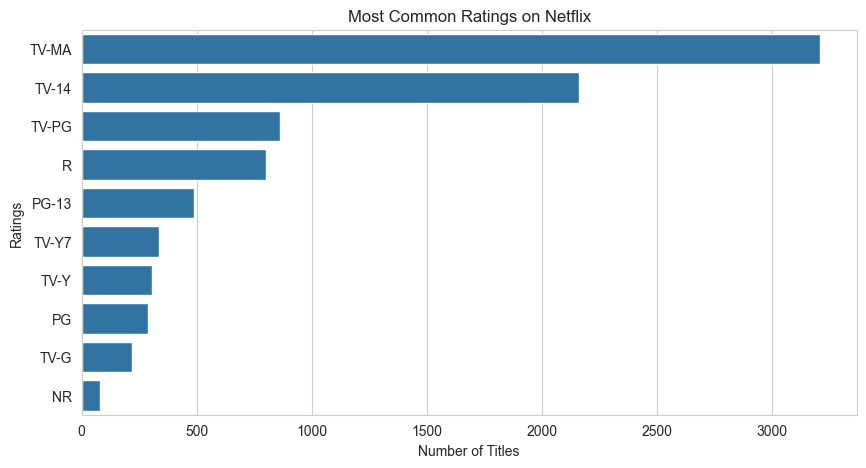

In [7]:
top_ratings = df["rating"].value_counts().head(10)
top_ratings
plt.figure(figsize=(10,5))
sns.barplot(x=top_ratings.values,y=top_ratings.index)
plt.title("Most Common Ratings on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Ratings")
plt.show()

### Insight

The most common ratings on Netflix are TV-MA and TV-14.
This suggests that a large portion of Netflix's content is targeted toward teenage and adult audiences rather than young children.


## Analysis 5: Most Common Genres on Netflix

This analysis examines the genres that appear most frequently in Netflix's catalog.
By analyzing genre distribution, we can understand the types of content that dominate the platform and identify popular categories among viewers.


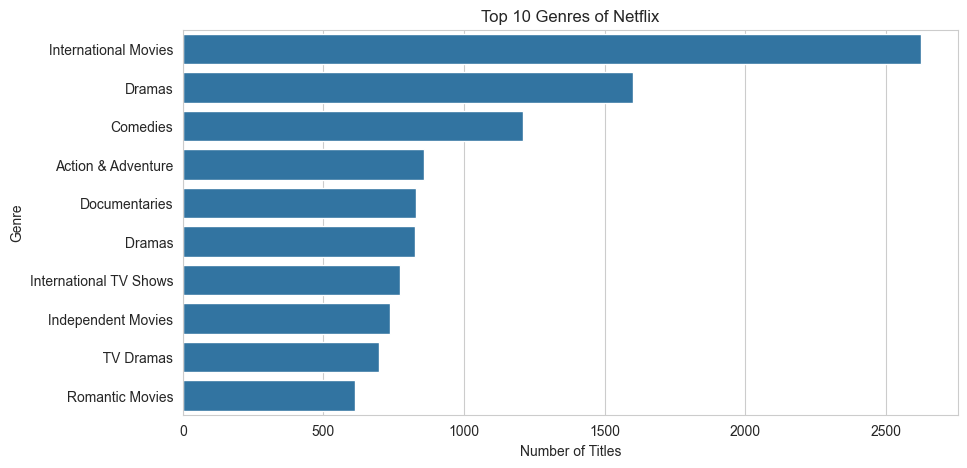

In [8]:
genres = df["listed_in"].str.split(",",expand=True).stack()
top_genres = genres.value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values,y=top_genres.index)
plt.title("Top 10 Genres of Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

## Key Insights

• Movies dominate Netflix's catalog compared to TV shows.

• Netflix experienced rapid growth in its content library after 2016.

• The United States contributes the largest number of titles on the platform.

• Most Netflix content is targeted toward mature and teenage audiences.

• Genres such as International Movies, Dramas, and Comedies are among the most common categories on Netflix.
